### Loading Dataset

In [1]:
import os
import numpy as np

BASE_DIR = os.path.dirname(os.getcwd())
IMAGE_DIR = os.path.join(BASE_DIR, "data/processed/images")
MASK_DIR = os.path.join(BASE_DIR, "data/processed/masks")

image_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print("Total samples:", len(image_files))

# Load one sample
img = np.load(os.path.join(IMAGE_DIR, image_files[0]))
mask = np.load(os.path.join(MASK_DIR, mask_files[0]))

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

Total samples: 3064
Image shape: (256, 256, 3)
Mask shape: (256, 256)


### Visualizing Samples

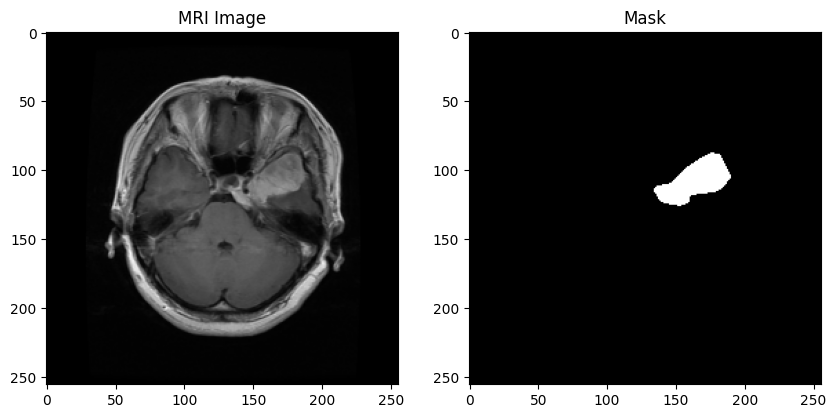

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("MRI Image")
plt.imshow(img)

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')

plt.show()

### Pixel intensity distribution
Helps understand normalization & contrast

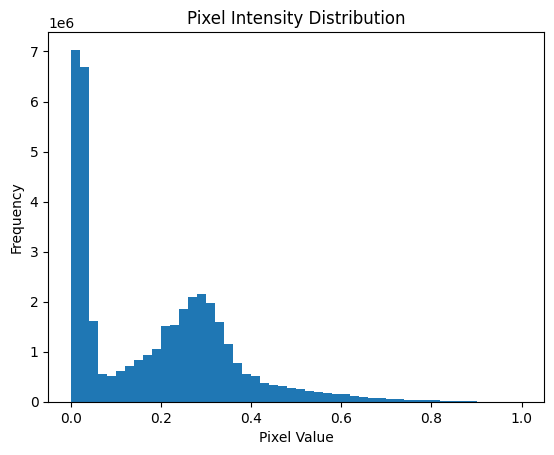

In [3]:
pixels = []

for file in image_files[:200]:  # sample subset
    img = np.load(os.path.join(IMAGE_DIR, file))
    pixels.extend(img.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

### Tumor size distribution
This detects class imbalance

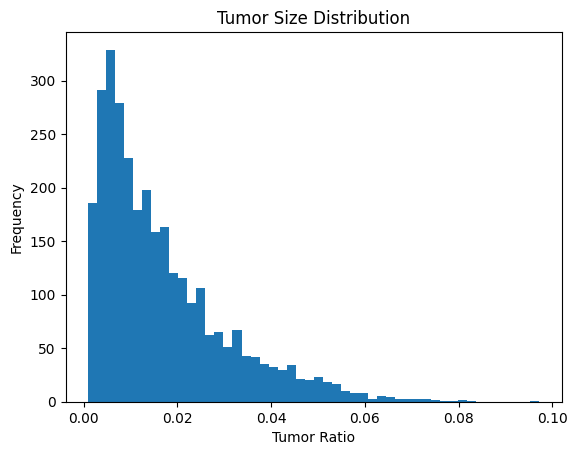

In [4]:
tumor_sizes = []

for file in mask_files:
    mask = np.load(os.path.join(MASK_DIR, file))
    tumor_pixels = np.sum(mask > 0)
    total_pixels = mask.size
    
    tumor_ratio = tumor_pixels / total_pixels
    tumor_sizes.append(tumor_ratio)

plt.hist(tumor_sizes, bins=50)
plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Ratio")
plt.ylabel("Frequency")
plt.show()

### Class Imbalance Check

In [5]:
empty = 0
non_empty = 0

for file in mask_files:
    mask = np.load(os.path.join(MASK_DIR, file))
    
    if np.sum(mask) == 0:
        empty += 1
    else:
        non_empty += 1

print("No tumor images:", empty)
print("Tumor images:", non_empty)

No tumor images: 0
Tumor images: 3064


### Show Extreme Cases

Smallest tumor:


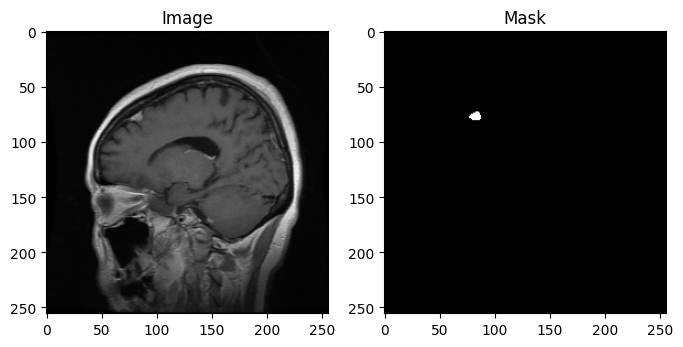

Largest tumor:


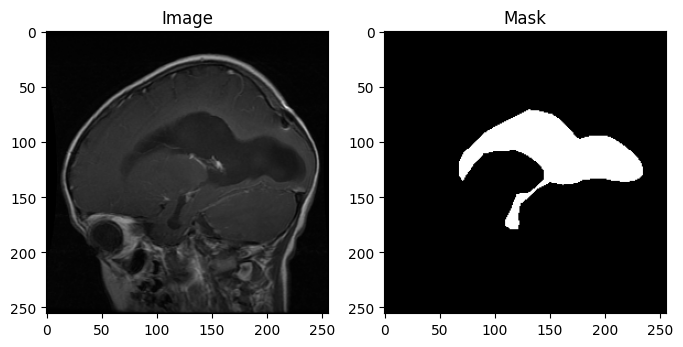

In [6]:
# Smallest tumor
min_idx = np.argmin(tumor_sizes)

# Largest tumor
max_idx = np.argmax(tumor_sizes)

def show_sample(idx):
    img = np.load(os.path.join(IMAGE_DIR, image_files[idx]))
    mask = np.load(os.path.join(MASK_DIR, mask_files[idx]))
    
    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image")
    
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    
    plt.show()

print("Smallest tumor:")
show_sample(min_idx)

print("Largest tumor:")
show_sample(max_idx)

### Correlation
Mean intensity vs tumor size

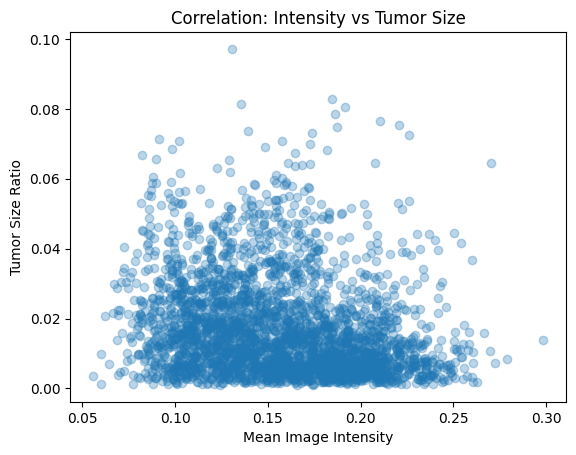

In [7]:
mean_intensity = []

for img_file, mask_file in zip(image_files, mask_files):
    img = np.load(os.path.join(IMAGE_DIR, img_file))
    mask = np.load(os.path.join(MASK_DIR, mask_file))
    
    mean_intensity.append(np.mean(img))

plt.scatter(mean_intensity, tumor_sizes, alpha=0.3)
plt.xlabel("Mean Image Intensity")
plt.ylabel("Tumor Size Ratio")
plt.title("Correlation: Intensity vs Tumor Size")
plt.show()

### Summary 
-  The dataset consists of 3064 MRI images, all containing tumor regions
-  No empty masks were found, confirming that the task is strictly segmentation rather than classification
-  Pixel intensity distributions indicate consistent preprocessing and suitable image quality
-  Tumor regions occupy a very small fraction of the image, leading to significant pixel-level class imbalance
-  No strong correlation was observed between image intensity and tumor size, suggesting that spatial and contextual features are essential for accurate segmentation
-  Visualization of extreme cases shows that:
- Small tumors are challenging to detect
-  Large tumors are easier and more prominent